# Exploratory Data Analysis

This notebook contains the loading and initial analysis of the APTOS 2019
Blindness Detection dataset. This dataset is protected by a Kaggle API token
because it belongs to a competition; it cannot be redistributed or used for
commercial purposes. The dataset was downloaded once and persisted to Google
Drive — this notebook loads it from there.

## Mount Google Drive in Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load dataset and verify integrity

In [2]:
import pandas as pd
import os

drive_path = '/content/drive/MyDrive/June/Final Project - Retinal Screening Triage System/data/raw/'

train_csv = pd.read_csv(os.path.join(drive_path, 'train.csv'))
n_images = len(os.listdir(os.path.join(drive_path, 'train_images')))

print(f"Rows in train.csv: {len(train_csv)}")
print(f"Images in train_images/: {n_images}")
assert len(train_csv) == n_images, "Mismatch between CSV and images!"

Rows in train.csv: 3662
Images in train_images/: 3662


## Basic structural exploration

In [11]:
print(train_csv.shape)
print(train_csv.dtypes)
train_csv.head()

(3662, 2)
id_code      object
diagnosis     int64
dtype: object


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [12]:
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_code    3662 non-null   object
 1   diagnosis  3662 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 57.3+ KB


In [13]:
train_csv['diagnosis'].describe()

,diagnosis
count,3662.000000
mean,1.126980
std,1.298409
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,4.000000


Note: `diagnosis` is an ordinal categorical variable (5 severity grades),
not continuous. Descriptive statistics like mean/std are shown for
completeness but are not clinically interpretable on their own —
`value_counts()` (see Class Distribution section below) is the meaningful
summary for this variable.

## Check for duplicate entries

In [10]:
duplicates = train_csv['id_code'].duplicated().sum()
print(f"Duplicate id_code entries: {duplicates}")

Duplicate id_code entries: 0


## Class distribution

In [3]:
train_csv['diagnosis'].value_counts().sort_index()

,count
diagnosis,
0,1805
1,370
2,999
3,193
4,295


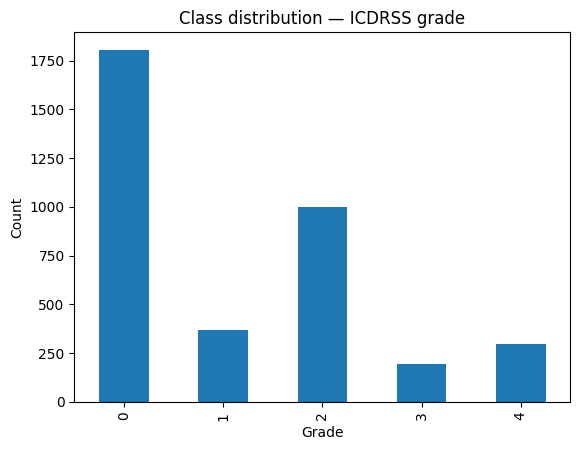

In [4]:
import matplotlib.pyplot as plt

train_csv['diagnosis'].value_counts().sort_index().plot(kind='bar')
plt.title('Class distribution — ICDRSS grade')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

## Class imbalance ratio

In [5]:
counts = train_csv['diagnosis'].value_counts().sort_index()
imbalance_ratio = counts[0] / counts[3]
print(f"Grade 0 vs Grade 3 imbalance ratio: {imbalance_ratio:.1f}:1")

Grade 0 vs Grade 3 imbalance ratio: 9.4:1


## Visual inspection: sample images per grade

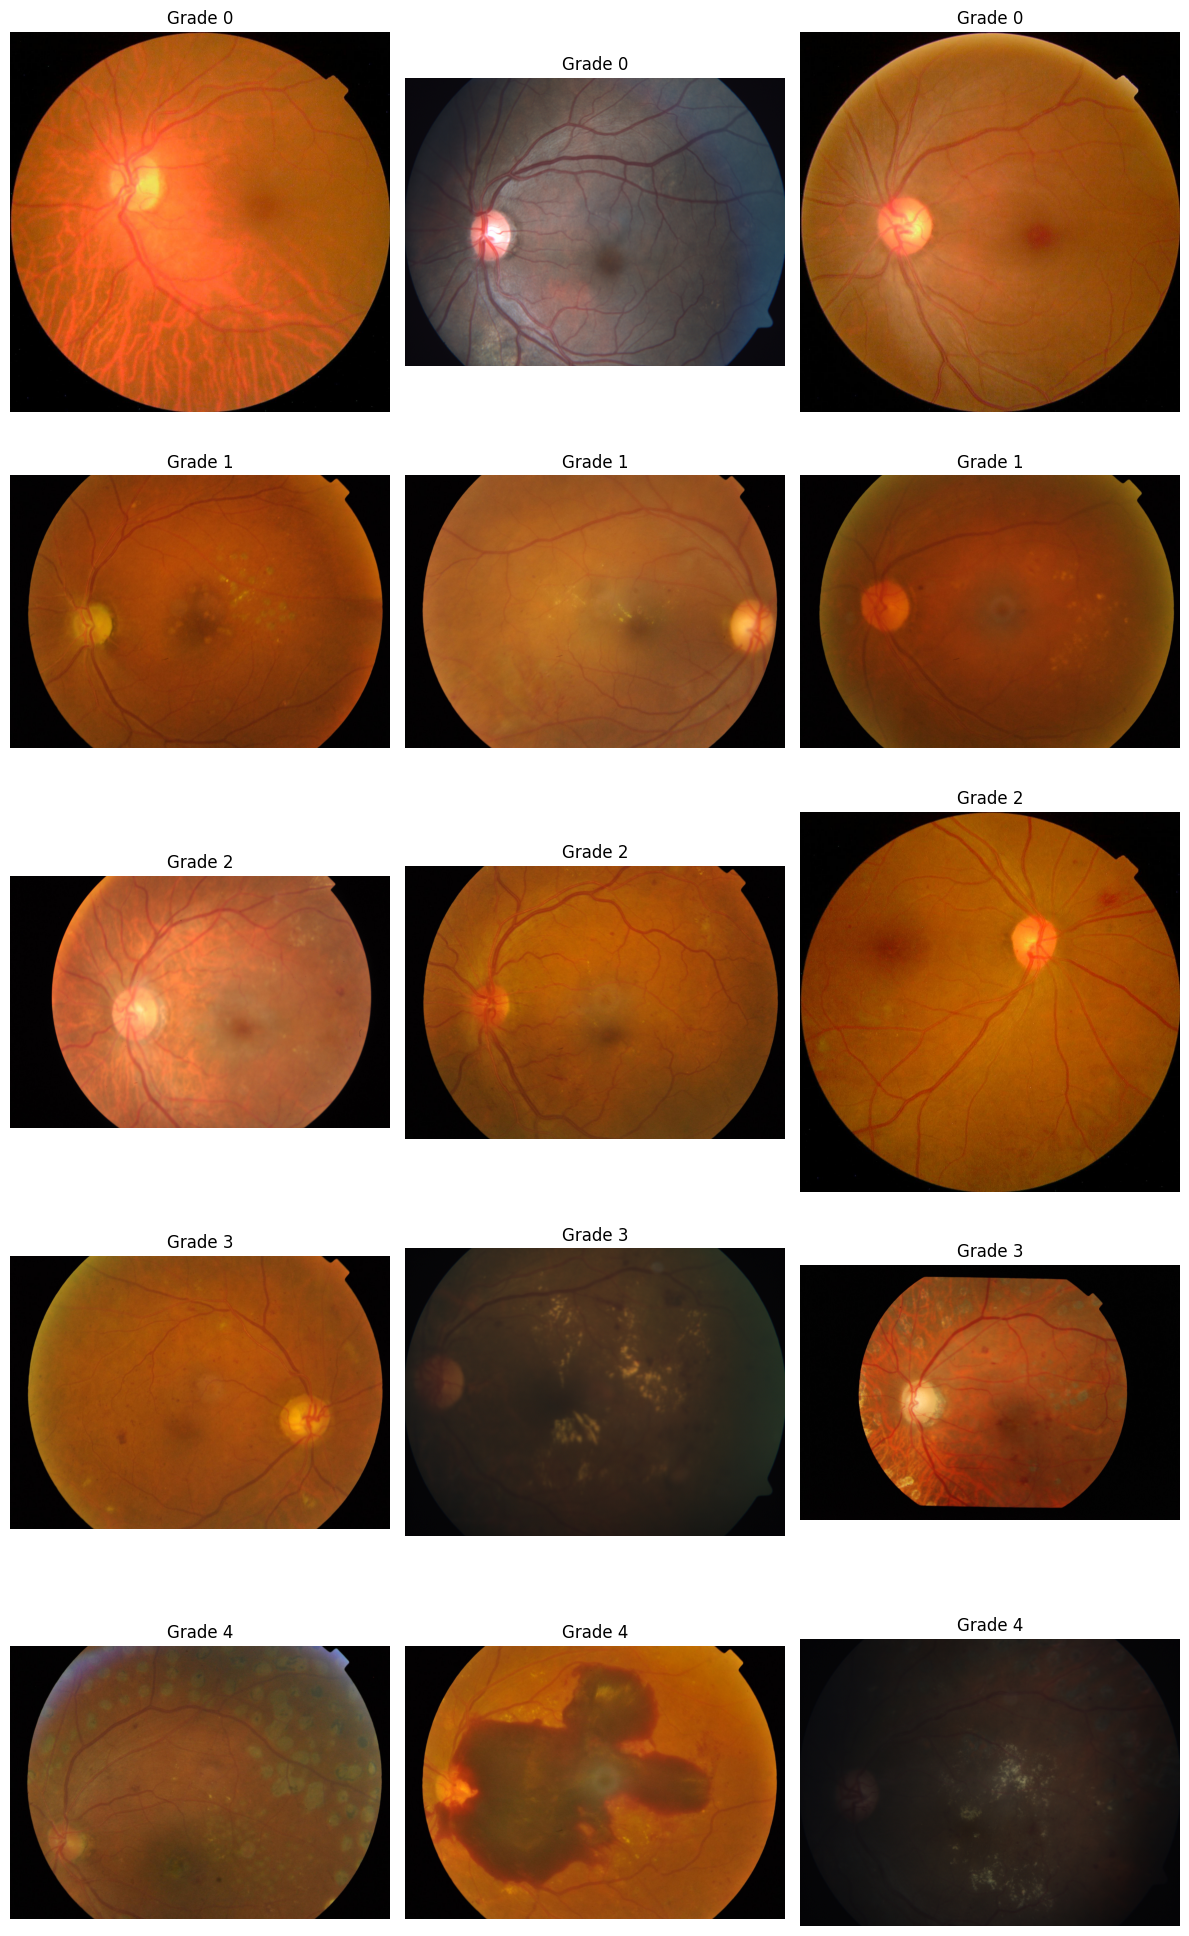

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(5, 3, figsize=(12, 20))

for grade in range(5):
    sample_ids = train_csv[train_csv['diagnosis'] == grade]['id_code'].sample(3, random_state=42).values
    for col, img_id in enumerate(sample_ids):
        img_path = os.path.join(drive_path, 'train_images', f'{img_id}.png')
        img = Image.open(img_path)
        axes[grade, col].imshow(img)
        axes[grade, col].set_title(f'Grade {grade}')
        axes[grade, col].axis('off')

plt.tight_layout()
plt.show()

Visual inspection — observations

Manual review of sample images across all five grades revealed meaningful
heterogeneity in image quality, independent of diagnosis:

- **Exposure**: several images are notably under-exposed (e.g. one Grade 3
  sample), making retinal structures barely distinguishable.
- **Framing/geometry**: not all images are circular fundus crops — at least
  one Grade 3 sample shows an octagonal crop, and field of view (zoom level)
  varies considerably between captures (e.g. Grade 2 samples).
- **Colour balance**: one Grade 0 sample shows an atypical blue/grey cast,
  suggesting a different camera or calibration than the rest of the set.
- **Possible artifacts**: one Grade 4 sample shows a large dark occlusion
  covering a substantial portion of the retina, more consistent with a
  capture artifact (e.g. eyelash, shadow)

## Extract image dimensions

In [7]:
from collections import Counter

dimensions = []
sample_ids = train_csv['id_code'].sample(200, random_state=42).values

for img_id in sample_ids:
    img_path = os.path.join(drive_path, 'train_images', f'{img_id}.png')
    with Image.open(img_path) as img:
        dimensions.append(img.size)

dim_counts = Counter(dimensions)
print("Most common dimensions:")
for dim, count in dim_counts.most_common(10):
    print(f"  {dim}: {count}")

Most common dimensions:
  (1050, 1050): 64
  (2588, 1958): 30
  (3216, 2136): 26
  (2416, 1736): 21
  (2048, 1536): 17
  (819, 614): 13
  (3388, 2588): 8
  (1844, 1226): 5
  (1504, 1000): 4
  (4288, 2848): 3


- **Resolution**: a 200-image sample revealed at least 10 distinct
  dimensions, ranging from 819×614 (~0.5 MP) to 4288×2848 (~12 MP) — a
  ~24x difference in pixel area. This confirms the dataset aggregates
  captures from multiple cameras/sources and justifies the resize-and-
  normalise step (Block 5) as a substantive preprocessing decision rather
  than a formality.

## Compute mean luminance for the same sample

Mean luminance: 68.2
Min luminance: 19.6
Max luminance: 106.0


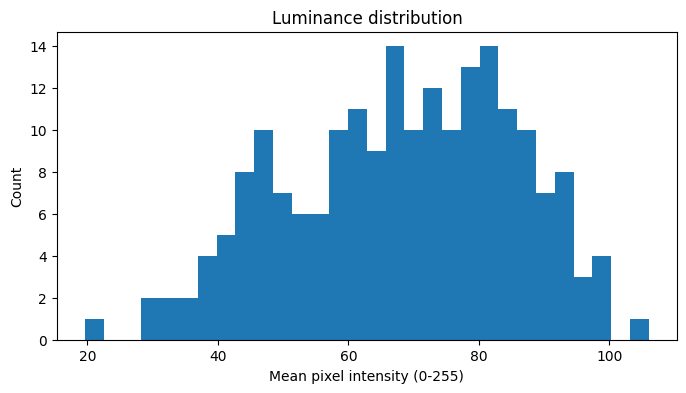

In [8]:
import numpy as np

luminances = []

for img_id in sample_ids:
    img_path = os.path.join(drive_path, 'train_images', f'{img_id}.png')
    with Image.open(img_path) as img:
        gray = img.convert('L')
        luminances.append(np.array(gray).mean())

print(f"Mean luminance: {np.mean(luminances):.1f}")
print(f"Min luminance: {np.min(luminances):.1f}")
print(f"Max luminance: {np.max(luminances):.1f}")

plt.figure(figsize=(8, 4))
plt.hist(luminances, bins=30)
plt.title('Luminance distribution')
plt.xlabel('Mean pixel intensity (0-255)')
plt.ylabel('Count')
plt.show()

- **Luminance**: mean pixel intensity across the sample is 68.2 (0-255
  scale), ranging from 19.6 (severely under-exposed) to 106.0
  (over-exposed). The distribution is roughly unimodal and centred between
  45-95, consistent with typical fundus photography, but the left tail
  (below ~35-40) corresponds to visibly unusable captures identified in
  the manual inspection above — candidates for exclusion or flagging by
  the quality gate stage.

## Save EDA summary for Tableau dashboard

In [9]:
## Save EDA summary for Tableau dashboard (Day 6)
eda_summary = pd.DataFrame({
    'id_code': sample_ids,
    'diagnosis': [train_csv[train_csv['id_code'] == img_id]['diagnosis'].values[0] for img_id in sample_ids],
    'width': [dim[0] for dim in [Image.open(os.path.join(drive_path, 'train_images', f'{img_id}.png')).size for img_id in sample_ids]],
    'height': [dim[1] for dim in [Image.open(os.path.join(drive_path, 'train_images', f'{img_id}.png')).size for img_id in sample_ids]],
    'mean_luminance': luminances
})

processed_path = '/content/drive/MyDrive/June/Final Project - Retinal Screening Triage System/data/processed/'
os.makedirs(processed_path, exist_ok=True)

eda_summary.to_csv(os.path.join(processed_path, 'eda_summary.csv'), index=False)
print(f"Saved: {os.path.join(processed_path, 'eda_summary.csv')}")
print(eda_summary.head())

Saved: /content/drive/MyDrive/June/Final Project - Retinal Screening Triage System/data/processed/eda_summary.csv
        id_code  diagnosis  width  height  mean_luminance
0  90960ddf4d14          0   2048    1536       30.223542
1  4e0656629d02          1   2588    1958       61.344004
2  3b018e8b7303          3   2588    1958       57.855091
3  55eb405ec71e          4   3388    2588       68.152354
4  207dd0487264          0   1050    1050       80.907170
